In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import json
import matplotlib.image as image
from matplotlib.ticker import FormatStrFormatter


In [2]:
#sys.path.insert(1, '/user/sebert/home/Documents/Simulations/osr_model/')
sys.path.insert(1, 'utils')


In [3]:
#from utils import load_dict, slope_fun
# from load_data import *
# from plot_functions import *
from utils_functions import *

In [4]:
def extract_source_data(ax,save_name,panel):

    lines = ax.get_lines()
    df = pd.DataFrame()
    
    for line in lines:

        try:
            lab = line.get_label()
            x = line.get_xdata()
            y = line.get_ydata()
            df[f'{lab}_x'] = x
            df[f'{lab}_y'] = y
        except:
            None

    df.to_csv(f'source_data/{save_name}{panel}.csv')

# Import Results 

In [5]:

fn = 12


# import params
with open(f'../output/params_final_nonlin/params.json') as json_file:
    params = json.load(json_file)
    print(params)

simulation_dict_dynamic = load_dict(f'../output/params_final_nonlin/simulation_osr_{fn}.pickle')
simulation_dict_fixed =  load_dict(f'../output/params_final_nonlin_fixed/simulation_osr_{fn}.pickle')

# get params
theta_B = params['params_model']['theta_B']
theta_A1 = params['params_model']['theta_A1']
theta_A2 = params['params_model']['theta_A2']

w_B = params['params_model']['w_B']
w_A1 = params['params_model']['w_A1']
w_A2 = params['params_model']['w_A2']

n_A1_star = params['params_model']['n_A1_star']


cm = params['params_model']['cm']


{'params_model': {'tau_B': 0.08, 'tau_A1': 0.085, 'tau_A2': 0.12, 'tau_G': 0.11, 'tau_VR': 0.003, 'w_B': 50.0, 'w_A1': -53.0, 'w_A2': -65.0, 'theta_A1': 0, 'theta_A2': -20.0, 'k_rec': 10.0, 'k_rel': 10.0, 'beta': 0.086, 'scale_mV': 20, 'slope': 12, 'threshold': 0.0, 'slope_on': 14, 'threshold_on': -0.5, 'max_val_on': 1, 'slope_off': 12, 'threshold_off': 0.5, 'max_val_off': 1, 'cm': 0.1, 'SFB': 250.0, 'SFA1': 235.2941176470588, 'SFA2': 166.66666666666669, 'n_A1_star': 1.0, 'theta_B': -26.0}, 'model_functions': None, 'hyperparameter': {'dt': 0.002, 'filterlength': 1, 'occupancy': 'dynamic', 'polarities': ['ON', 'OFF', 'ON']}}


In [6]:
# load data from simulation with and without occupancy, slow freq

time = simulation_dict_dynamic['simulations']['6_Hz']['time']
lastflashend_6Hz = simulation_dict_dynamic['simulations']['6_Hz']['lastflash_tp']

time_6Hz = time-lastflashend_6Hz

stim_6Hz = simulation_dict_dynamic['simulations']['6_Hz']['stimulus']
sol_6Hz = simulation_dict_dynamic['simulations']['6_Hz']['sol']
sol_fixed_6Hz = simulation_dict_fixed['simulations']['6_Hz']['sol']

delay_fixed_6Hz = simulation_dict_fixed['simulations']['6_Hz']["delay"]
amp_fixed_6Hz = simulation_dict_fixed['simulations']['6_Hz']["peak_amplitude"]


delay_6Hz = simulation_dict_dynamic['simulations']['6_Hz']["delay"]
amp_6Hz = simulation_dict_dynamic['simulations']['6_Hz']["peak_amplitude"]


VB_6Hz = sol_6Hz.y[0] 
VA1_6Hz = sol_6Hz.y[1] 
VA2_6Hz = sol_6Hz.y[2] 
nA1_6Hz = sol_6Hz.y[3] 

VG_6Hz = sol_6Hz.y[-1] 
VG_fixed_6Hz = sol_fixed_6Hz.y[-1] 

IB_6Hz =  VB_6Hz*w_B * cm
IA1_6Hz = VA1_6Hz*nA1_6Hz*w_A1 * cm
IA1_fixed_6Hz = VA1_6Hz*n_A1_star*w_A1 * cm
IA2_6Hz = VA2_6Hz*w_A2 * cm


RG_6Hz = simulation_dict_dynamic['simulations']['6_Hz']['RG'] 
RG_fixed_6Hz = simulation_dict_fixed['simulations']['6_Hz']['RG'] 


flashes_6Hz = np.where(np.diff(stim_6Hz) != 0)[0].tolist()

# load data from simulation with and without occupancy, medium freq

time = simulation_dict_dynamic['simulations']['12_Hz']['time']
lastflashend_12Hz = simulation_dict_dynamic['simulations']['12_Hz']['lastflash_tp']

time_12Hz = time-lastflashend_12Hz

stim_12Hz = simulation_dict_dynamic['simulations']['12_Hz']['stimulus']
sol_12Hz = simulation_dict_dynamic['simulations']['12_Hz']['sol']
sol_fixed_12Hz = simulation_dict_fixed['simulations']['12_Hz']['sol']

delay_fixed_12Hz = simulation_dict_fixed['simulations']['12_Hz']["delay"]
amp_fixed_12Hz = simulation_dict_fixed['simulations']['12_Hz']["peak_amplitude"]


delay_12Hz = simulation_dict_dynamic['simulations']['12_Hz']["delay"]
amp_12Hz = simulation_dict_dynamic['simulations']['12_Hz']["peak_amplitude"]


VB_12Hz = sol_12Hz.y[0] 
VA1_12Hz = sol_12Hz.y[1] 
VA2_12Hz = sol_12Hz.y[2] 
nA1_12Hz = sol_12Hz.y[3] 

VG_12Hz = sol_12Hz.y[-1] 
VG_fixed_12Hz = sol_fixed_12Hz.y[-1]  

IB_12Hz =  VB_12Hz*w_B  * cm
IA1_12Hz = VA1_12Hz*nA1_12Hz*w_A1 * cm
IA1_fixed_12Hz = VA1_12Hz*n_A1_star*w_A1 * cm
IA2_12Hz = VA2_12Hz*w_A2 * cm


RG_12Hz = simulation_dict_dynamic['simulations']['12_Hz']['RG'] 
RG_fixed_12Hz = simulation_dict_fixed['simulations']['12_Hz']['RG'] 


flashes_12Hz = np.where(np.diff(stim_12Hz) != 0)[0].tolist()

# load data from simulation with and without occupancy, fast freq
time = simulation_dict_dynamic['simulations']['16_Hz']['time']
lastflashend_16Hz = simulation_dict_dynamic['simulations']['16_Hz']['lastflash_tp']

time_16Hz = time-lastflashend_16Hz 

stim_16Hz = simulation_dict_dynamic['simulations']['16_Hz']['stimulus']
sol_16Hz = simulation_dict_dynamic['simulations']['16_Hz']['sol']
sol_fixed_16Hz = simulation_dict_fixed['simulations']['16_Hz']['sol']

delay_fixed_16Hz = simulation_dict_fixed['simulations']['16_Hz']["delay"]
amp_fixed_16Hz = simulation_dict_fixed['simulations']['16_Hz']["peak_amplitude"]


delay_16Hz = simulation_dict_dynamic['simulations']['16_Hz']["delay"]
amp_16Hz = simulation_dict_dynamic['simulations']['16_Hz']["peak_amplitude"]


VB_16Hz = sol_16Hz.y[0] 
VA1_16Hz = sol_16Hz.y[1] 
VA2_16Hz = sol_16Hz.y[2] 
nA1_16Hz = sol_16Hz.y[3] 

VG_16Hz = sol_16Hz.y[-1] 
VG_fixed_16Hz = sol_fixed_16Hz.y[-1] 

IB_16Hz =  VB_16Hz*w_B  * cm
IA1_16Hz = VA1_16Hz*nA1_16Hz*w_A1 * cm
IA1_fixed_16Hz = VA1_16Hz*n_A1_star*w_A1 * cm
IA2_16Hz = VA2_16Hz*w_A2 * cm


RG_16Hz = simulation_dict_dynamic['simulations']['16_Hz']['RG'] 
RG_fixed_16Hz = simulation_dict_fixed['simulations']['16_Hz']['RG'] 


flashes_16Hz = np.where(np.diff(stim_16Hz) != 0)[0].tolist()



# load occupancy information
maxs_n = simulation_dict_dynamic['maxs_n']
periods = simulation_dict_dynamic['osrparams']['periods']
frequencies = simulation_dict_dynamic['osrparams']['frequencies']

# Make Figure 

In [7]:
#figure parameter

fontsize_legend = 15
fontsize_labels = 25
fontsize_panellabel = 30
fontsize_ticks = 20
lw = 3
ms = 65
panellabel_position = [-0.1, 1.15]
frequencytext_position = [0.15,1.1]
figsize_col = (6,20)

#figure parameter
save = True
figure_name = "Figure_5"
show = True
image_format = "png"
dpi = 300



# Panel A: Internal Variables for 2 Frequencies

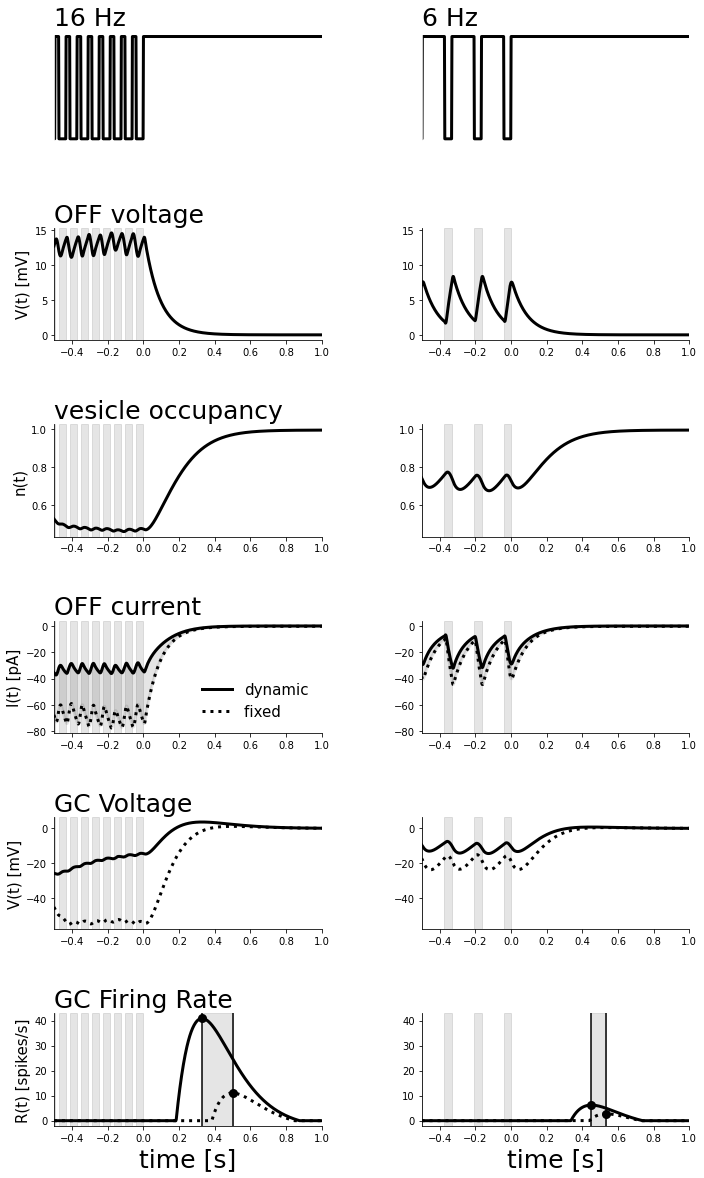

In [8]:
#%matplotlib qt
#####################################################################################################################
# panel A
#####################################################################################################################

#initialize figure
fig = plt.figure(figsize = (12,20))
gs = fig.add_gridspec(6,2)
fig.tight_layout()


B = fig.add_subplot(gs[0:,0], frameon = False)
C = fig.add_subplot(gs[0:,1], frameon = False)


B0 = fig.add_subplot(gs[0,0]) # stimulus 
B1 = fig.add_subplot(gs[1,0],sharex = B0) # OFF voltage
B2 = fig.add_subplot(gs[2,0],sharex = B0) # OFF occupancy
B3 = fig.add_subplot(gs[3,0],sharex = B0) # OFF currents
B4 = fig.add_subplot(gs[4,0],sharex = B0) # GC Voltage
B5 = fig.add_subplot(gs[5,0],sharex = B0) # GC R(t)

C0 = fig.add_subplot(gs[0,1]) # stimulus 
C1 = fig.add_subplot(gs[1,1],sharex = C0, sharey = B1) # OFF voltage
C2 = fig.add_subplot(gs[2,1],sharex = C0, sharey = B2) # OFF occupancy
C3 = fig.add_subplot(gs[3,1],sharex = C0, sharey = B3) # OFF currents
C4 = fig.add_subplot(gs[4,1],sharex = C0, sharey = B4) # GC Voltage
C5 = fig.add_subplot(gs[5,1],sharex = C0, sharey = B5) # GC R(t)


# B.text(*panellabel_position, 'A', transform=B.transAxes,
#       fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
# C.text(*panellabel_position, 'C', transform=C.transAxes,
#      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')




# remove frames that are not needed


B0.spines['right'].set_visible(False)
B0.spines['top'].set_visible(False)
B1.spines['right'].set_visible(False)
B1.spines['top'].set_visible(False)
B2.spines['right'].set_visible(False)
B2.spines['top'].set_visible(False)
B3.spines['right'].set_visible(False)
B3.spines['top'].set_visible(False)
B4.spines['right'].set_visible(False)
B4.spines['top'].set_visible(False)
B5.spines['right'].set_visible(False)
B5.spines['top'].set_visible(False)

C0.spines['right'].set_visible(False)
C0.spines['top'].set_visible(False)
C1.spines['right'].set_visible(False)
C1.spines['top'].set_visible(False)
C2.spines['right'].set_visible(False)
C2.spines['top'].set_visible(False)
C3.spines['right'].set_visible(False)
C3.spines['top'].set_visible(False)
C4.spines['right'].set_visible(False)
C4.spines['top'].set_visible(False)
C5.spines['right'].set_visible(False)
C5.spines['top'].set_visible(False)

B.set_xticks([])
B.set_yticks([])
C.set_xticks([])
C.set_yticks([])


B0.spines['left'].set_color('white')
B0.tick_params(axis='y', colors='white')
B0.spines['bottom'].set_color('white')
B0.tick_params(axis='x', colors='white')

C0.spines['left'].set_color('white')
C0.tick_params(axis='y', colors='white')
C0.spines['bottom'].set_color('white')
C0.tick_params(axis='x', colors='white')



# set axis range
B0.set_xlim(-.5,1)
C0.set_xlim(-.5,1)


#label the axis

B1.set_ylabel('V(t) [mV]',fontsize = fontsize_legend)
B2.set_ylabel('n(t)',fontsize = fontsize_legend)
B3.set_ylabel('I(t) [pA]',fontsize = fontsize_legend)
B4.set_ylabel('V(t) [mV]',fontsize = fontsize_legend)
B5.set_ylabel('R(t) [spikes/s]',fontsize = fontsize_legend)


B5.set_xlabel('time [s]', fontsize = fontsize_labels)
C5.set_xlabel('time [s]', fontsize = fontsize_labels)


# set titles

B1.set_title('OFF voltage ',fontsize = fontsize_labels, loc = 'left')
B2.set_title('vesicle occupancy',fontsize = fontsize_labels, loc = 'left')
B3.set_title('OFF current ',fontsize = fontsize_labels, loc = 'left')
B4.set_title('GC Voltage ',fontsize = fontsize_labels, loc = 'left')
B5.set_title('GC Firing Rate ',fontsize = fontsize_labels, loc = 'left')

B0.set_title('16 Hz',fontsize = fontsize_labels, loc = 'left')
C0.set_title('6 Hz',fontsize = fontsize_labels, loc = 'left')


fig.subplots_adjust(top=0.87,
bottom=0.11,
left=0.165,
right=0.9,
hspace=0.745,
wspace=0.375)



#####################################################################################################################
# fill panels
#####################################################################################################################



# panel 2 : occupancy effect for slow frequency

for i in range(len(flashes_16Hz)):  
    if  not i % 2 :
        B1.axvspan(time_16Hz[flashes_16Hz[i]], time_16Hz[flashes_16Hz[i+1]+1], color = 'k', alpha = 0.1)
        B2.axvspan(time_16Hz[flashes_16Hz[i]], time_16Hz[flashes_16Hz[i+1]+1], color = 'k', alpha = 0.1)
        B3.axvspan(time_16Hz[flashes_16Hz[i]], time_16Hz[flashes_16Hz[i+1]+1], color = 'k', alpha = 0.1)
        B4.axvspan(time_16Hz[flashes_16Hz[i]], time_16Hz[flashes_16Hz[i+1]+1], color = 'k', alpha = 0.1)
        B5.axvspan(time_16Hz[flashes_16Hz[i]], time_16Hz[flashes_16Hz[i+1]+1], color = 'k', alpha = 0.1)





B0.plot(time_16Hz,stim_16Hz, color = 'k', linewidth = lw, label = '_stimulus')
B1.plot(time_16Hz,VA1_16Hz, color = 'black', linewidth = lw, label = '_V_I_OFF')
B2.plot(time_16Hz,nA1_16Hz, color = 'black', linewidth = lw, label = '_n_I_OFF')


B3.plot(time_16Hz,IA1_16Hz - IA1_16Hz[100], color = 'black', label = 'dynamic', linewidth = lw)
B3.plot(time_16Hz,IA1_fixed_16Hz - IA1_fixed_16Hz[0], linestyle = ':', color = 'black', label = 'fixed ', linewidth = lw)
B3.legend(fontsize = fontsize_legend,frameon = False)

B3.fill_between(time_16Hz,IA1_16Hz - IA1_16Hz[100],IA1_fixed_16Hz - IA1_fixed_16Hz[0], color = 'k',alpha = 0.1, linewidth = lw)

B4.plot(time_16Hz,VG_16Hz, color = 'black', label = 'dynamic', linewidth = lw)
B4.plot(time_16Hz,VG_fixed_16Hz, color = 'black',linestyle = ':', label = 'fixed', linewidth = lw)

B5.plot(time_16Hz,RG_16Hz, color = 'black', linewidth = lw, label = '_dynamic')
B5.plot(time_16Hz,RG_fixed_16Hz, color = 'black', linestyle = ':', linewidth = lw, label = '_fixed')


B5.scatter(delay_16Hz,amp_16Hz, color = 'black', linewidth = lw)
B5.scatter(delay_fixed_16Hz,amp_fixed_16Hz, color = 'black', linewidth = lw)

B5.axvline(delay_16Hz, color = 'black')
B5.axvline(delay_fixed_16Hz, color = 'black') 
B5.axvspan(delay_16Hz,delay_fixed_16Hz, color = 'black', alpha = 0.1)


# B1.legend(fontsize = fontsize_legend)
# B2.legend(fontsize = fontsize_legend)
# B3.legend(fontsize = fontsize_legend)
# B4.legend(fontsize = fontsize_legend)

panel = 'A1_left'
extract_source_data(B1,figure_name,panel)
panel = 'A2_left'
extract_source_data(B2,figure_name,panel)
panel = 'A3_left'
extract_source_data(B3,figure_name,panel)
panel = 'A4_left'
extract_source_data(B4,figure_name,panel)
panel = 'A5_left'
extract_source_data(B5,figure_name,panel)

# panel 3 : occupancy effect for fast frequency

for i in range(len(flashes_6Hz)):  
    if  not i % 2 :
        C1.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        C2.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        C3.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        C4.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        C5.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)





C0.plot(time_6Hz,stim_6Hz, color = 'k', linewidth = lw, label = '_stimulus')
C1.plot(time_6Hz,VA1_6Hz, color = 'black', linewidth = lw, label = '_V_OFF')
C2.plot(time_6Hz,nA1_6Hz, color = 'black', linewidth = lw, label = '_n_OFF')


C3.plot(time_6Hz,IA1_6Hz - IA1_6Hz[100], color = 'black', linewidth = lw, label= '_dynamic')
C3.plot(time_6Hz,IA1_fixed_6Hz - IA1_fixed_6Hz[0], linestyle = ':', color = 'black', linewidth = lw, label = '_fixed')

C3.fill_between(time_6Hz,IA1_6Hz - IA1_6Hz[100],IA1_fixed_6Hz - IA1_fixed_6Hz[0], color = 'k',alpha = 0.1, linewidth = lw)

C4.plot(time_6Hz,VG_6Hz, color = 'black', linewidth = lw, label = '_dynamic')
C4.plot(time_6Hz,VG_fixed_6Hz, color = 'black', linestyle = ':', linewidth = lw, label = '_fixed')

C5.plot(time_6Hz,RG_6Hz, color = 'black', linewidth = lw, label = '_dynamic')
C5.plot(time_6Hz,RG_fixed_6Hz, color = 'black', linestyle = ':', linewidth = lw, label = '_fixed')


C5.scatter(delay_6Hz,amp_6Hz, color = 'black', linewidth = lw, label = '_dynamic')
C5.scatter(delay_fixed_6Hz,amp_fixed_6Hz, color = 'black', linewidth = lw, label = '_fixed')

C5.axvline(delay_6Hz, color = 'black')
C5.axvline(delay_fixed_6Hz, color = 'black') 
C5.axvspan(delay_6Hz,delay_fixed_6Hz, color = 'black', alpha = 0.1)



panel = 'A1_right'
extract_source_data(C1,figure_name,panel)
panel = 'A2_right'
extract_source_data(C2,figure_name,panel)
panel = 'A3_right'
extract_source_data(C3,figure_name,panel)
panel = 'A4_right'
extract_source_data(C4,figure_name,panel)
panel = 'A5_right'
extract_source_data(C5,figure_name,panel)
# C1.legend(fontsize = fontsize_legend)
# C2.legend(fontsize = fontsize_legend)
# C3.legend(fontsize = fontsize_legend)
# C4.legend(fontsize = fontsize_legend)


# Panel B: n(t) for different frequenices

6
8
10
12
16


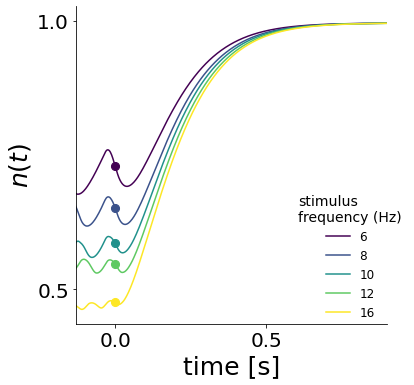

In [9]:



#initialize figure
fig = plt.figure(figsize = (6,6))
gs = fig.add_gridspec(1,1)

B = fig.add_subplot(gs[0:,0])


B.spines['top'].set_visible(False)
B.spines['right'].set_visible(False)

B.locator_params(axis = 'x', nbins=2)
B.locator_params(axis = 'y', nbins=2)


B.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
B.tick_params(axis='both', which='major', labelsize=fontsize_ticks)


B.set_ylabel('$n (t) $', fontsize = fontsize_labels)
B.set_xlabel('time [s]', fontsize = fontsize_labels)

shades_of_blue = plt.get_cmap('viridis',5)

fig.subplots_adjust(top=0.845,
bottom=0.11,
left=0.16,
right=0.88,
hspace=0.745,
wspace=0.375)

B.set_xlim(-.13,0.9)


#####################################################################################################################
# fill panels
#####################################################################################################################



ns_at_0 = []
for i, key in enumerate(simulation_dict_dynamic['simulations']):
    
    frequency = key[:-3]
    print(frequency)

    time = simulation_dict_dynamic['simulations'][key]["time"]
    lastflashend = simulation_dict_dynamic['simulations'][key]['lastflash_tp']
    sol = simulation_dict_dynamic['simulations'][key]['sol']
    n_at_0 = sol.y[3][np.where((time-lastflashend) == 0)[0]]
    B.plot(time-lastflashend,sol.y[3], label = key[:-3], color=shades_of_blue(i))
    B.scatter(0, n_at_0, s = ms, color= shades_of_blue(i))
    ns_at_0.append(n_at_0)
    
lg = B.legend(frameon=False, fontsize = 12, title = "stimulus\nfrequency (Hz)", title_fontsize=14,
             loc = (.7,0))

# Panel C: occupancy scaling with period

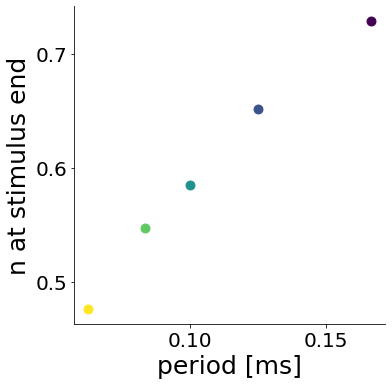

In [10]:



#initialize figure
fig = plt.figure(figsize = (6,6))
gs = fig.add_gridspec(1,1)

C = fig.add_subplot(gs[0:,0])


C.spines['top'].set_visible(False)
C.spines['right'].set_visible(False)

C.locator_params(axis = 'x', nbins=2)
C.locator_params(axis = 'y', nbins=2)


C.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
C.tick_params(axis='both', which='major', labelsize=fontsize_ticks)


C.set_ylabel('n at stimulus end', fontsize = fontsize_labels)
C.set_xlabel('period [ms]', fontsize = fontsize_labels)

shades_of_blue = plt.get_cmap('viridis',5)

fig.subplots_adjust(top=0.845,
bottom=0.11,
left=0.16,
right=0.88,
hspace=0.745,
wspace=0.375)



#####################################################################################################################
# fill panels
#####################################################################################################################

for i,mn in enumerate(ns_at_0):
    C.scatter(periods[i],
              mn,
              s = 80, 
              marker ='o', 
              zorder = 2, 
              color = shades_of_blue(i))




In [11]:
ms

65

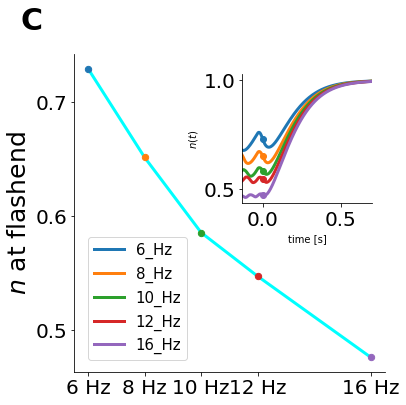

In [12]:
ms = 40

#####################################################################################################################
# panel C: n vs frequency
#####################################################################################################################

#initialize figure
fig = plt.figure(figsize = (6,6))
gs = fig.add_gridspec(1,1)
fig.tight_layout()


C = fig.add_subplot(gs[0:,0])


# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.55, 0.5, 0.3, 0.3]
Ci = fig.add_axes([left, bottom, width, height])


# add panel labels

C.text(*panellabel_position, 'C', transform=C.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')



# remove frames that are not needed

C.spines['top'].set_visible(False)
C.spines['right'].set_visible(False)
Ci.spines['top'].set_visible(False)
Ci.spines['right'].set_visible(False)

C.locator_params(axis = 'y', nbins=3)
Ci.locator_params(axis = 'x', nbins=2)
Ci.locator_params(axis = 'y', nbins=2)


C.set_xticks(frequencies)
C.set_xticklabels(['6 Hz','8 Hz','10 Hz','12 Hz', '16 Hz'])
C.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
C.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
Ci.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
Ci.tick_params(axis='both', which='major', labelsize=fontsize_ticks)


C.set_ylabel("$n$ at flashend",  fontsize = fontsize_labels)
Ci.set_ylabel('$n (t) $')
Ci.set_xlabel('time [s]')


fig.subplots_adjust(top=0.845,
bottom=0.11,
left=0.16,
right=0.88,
hspace=0.745,
wspace=0.375)

Ci.set_xlim(-.13,0.7)


#####################################################################################################################
# fill panels
#####################################################################################################################



ns_at_0 = []
for key in simulation_dict_dynamic['simulations']:

    time = simulation_dict_dynamic['simulations'][key]["time"]
    lastflashend = simulation_dict_dynamic['simulations'][key]['lastflash_tp']
    sol = simulation_dict_dynamic['simulations'][key]['sol']
    n_at_0 = sol.y[3][np.where((time-lastflashend) == 0)[0]]
    Ci.plot(time-lastflashend,sol.y[3], label = key, linewidth = lw)
    Ci.scatter(0, n_at_0)
    ns_at_0.append(n_at_0)
    
fig.legend(fontsize = fontsize_legend,bbox_to_anchor = (.44,.44))
#fig.legend(fontsize = fontsize_legend, bbox_to_anchor = (1,1))

C.plot(frequencies,ns_at_0, color = 'cyan', linewidth = lw, zorder = 1)

for i,mn in enumerate(ns_at_0):
    C.scatter(frequencies[i],mn,s = ms, marker ='o', zorder = 2)



# Panel C: n versus frequency with inlet

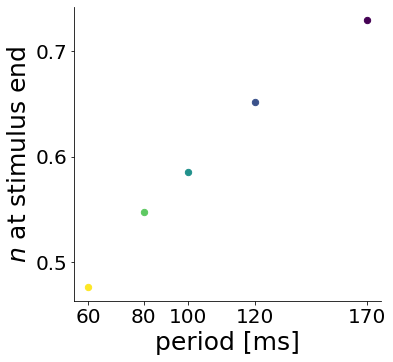

In [13]:
#####################################################################################################################
# panel C: n vs period
#####################################################################################################################

#initialize figure
fig = plt.figure(figsize = (6,6))
gs = fig.add_gridspec(1,1)
fig.tight_layout()


C = fig.add_subplot(gs[0:,0])


# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.5, 0.2, 0.3, 0.3]
#Ci = fig.add_axes([left, bottom, width, height])


# add panel labels

# C.text(*panellabel_position, 'B', transform=C.transAxes,
#       fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')



# remove frames that are not needed

C.spines['top'].set_visible(False)
C.spines['right'].set_visible(False)
# Ci.spines['top'].set_visible(False)
# Ci.spines['right'].set_visible(False)

C.locator_params(axis = 'y', nbins=3)
# Ci.locator_params(axis = 'x', nbins=2)
# Ci.locator_params(axis = 'y', nbins=2)


C.set_xticks(periods)
C.set_xticklabels(['170', '120'  , '100' , '80', '60'])
C.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
C.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
# Ci.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
# Ci.tick_params(axis='both', which='major', labelsize=fontsize_ticks)


C.set_ylabel("$n$ at stimulus end",  fontsize = fontsize_labels)
C.set_xlabel("period [ms]",  fontsize = fontsize_labels)
# Ci.set_ylabel('$n (t) $',  fontsize = fontsize_labels*0.8)
# Ci.set_xlabel('time [s]',  fontsize = fontsize_labels*0.8)


# Ci.set_xlim(-.13,0.7)

fig.subplots_adjust(top=0.845,
bottom=0.165,
left=0.17,
right=0.88,
hspace=0.745,
wspace=0.375)

#####################################################################################################################
# fill panels
#####################################################################################################################



ns_at_0 = []
for key in simulation_dict_dynamic['simulations']:

    time = simulation_dict_dynamic['simulations'][key]["time"]
    lastflashend = simulation_dict_dynamic['simulations'][key]['lastflash_tp']
    sol = simulation_dict_dynamic['simulations'][key]['sol']
    n_at_0 = sol.y[3][np.where((time-lastflashend) == 0)[0]]
#     Ci.plot(time-lastflashend,sol.y[3], label = key, linewidth = lw)
#     Ci.scatter(0, n_at_0)
    ns_at_0.append(n_at_0)
    

    #fig.legend(fontsize = fontsize_legend*0.8, bbox_to_anchor = (1.0,.5))
#fig.legend(fontsize = fontsize_legend, bbox_to_anchor = (1,1))

#C.plot(periods,ns_at_0, color = 'cyan', linewidth = lw, zorder = 1)

for i,mn in enumerate(ns_at_0):
    C.scatter(periods[i],mn,s = ms,color=shades_of_blue(i), marker ='o', zorder = 2)



# All panels together

6
8
10
12
16


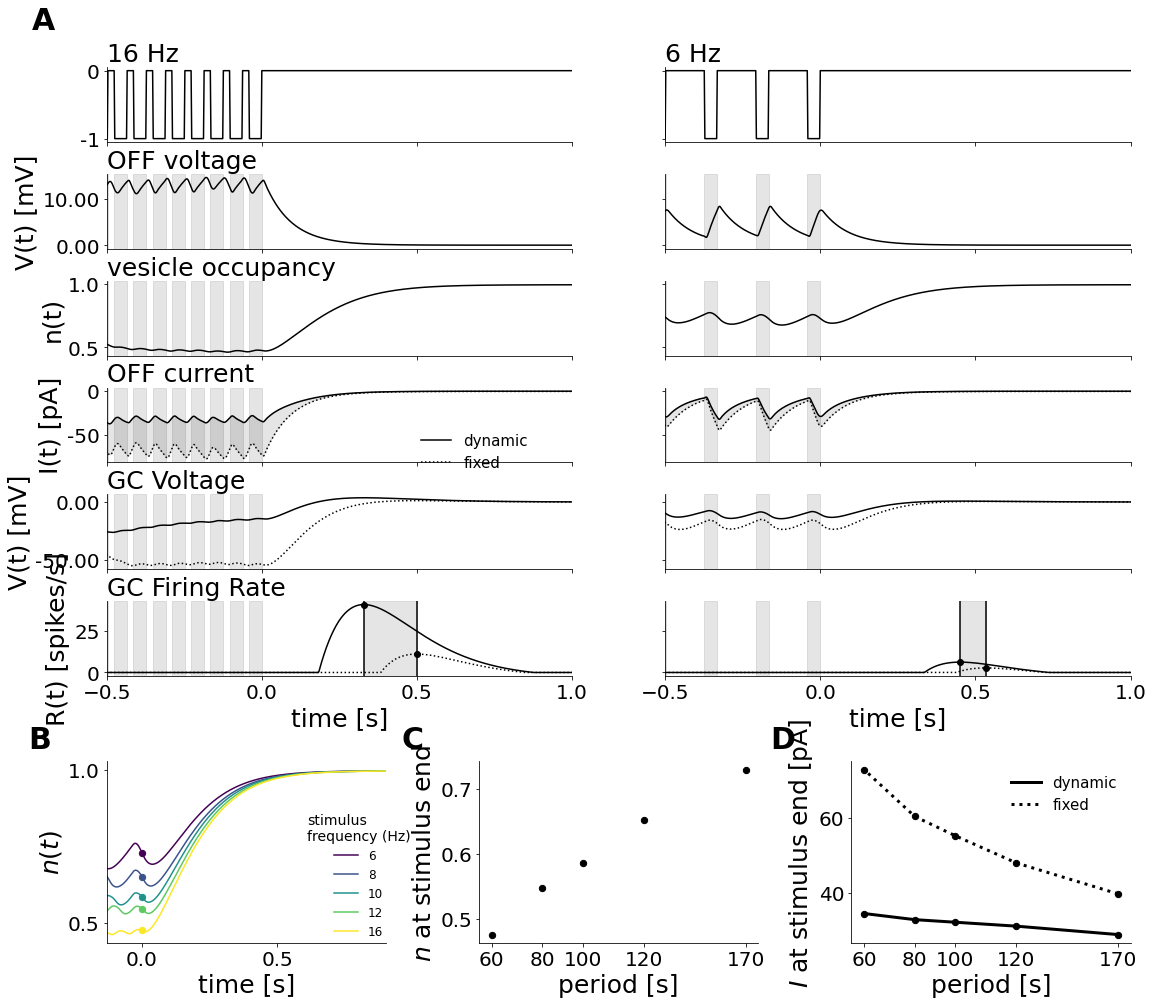

In [15]:

# fontsize_legend = 20
# fontsize_labels = 20
# fontsize_panellabel = 30
# fontsize_ticks = 15
# lw = 3
# ms = 40
panellabel_position = [-0.2, 1.2]
frequencytext_position = [0.15,1.1]
figsize_full = (18,16)

#initialize figure
fig = plt.figure(figsize= figsize_full)
gs = fig.add_gridspec(17,6)
fig.patch.set_facecolor('white')


#shades_of_green = ["darkgreen","forestgreen","seagreen","mediumseagreen","springgreen"]

# shades_of_blue = 5*["k"]
# shades_of_green = 5*["k"]


#####################################################################################################################
# create panels
#####################################################################################################################

A = fig.add_subplot(gs[0:12,:]) # Internal variables for two frequencies
B = fig.add_subplot(gs[13:,:2])  # Occupancy traces for all frequencies
C = fig.add_subplot(gs[13:,2:4]) # Occupancy scaling with frequency
D = fig.add_subplot(gs[13:,4:])  # Current re-scaling due to occupancy



A00 = fig.add_subplot(gs[0:2,3:]) # stimulus 
A10 = fig.add_subplot(gs[2:4,3:],sharex = A00) # OFF voltage
A20 = fig.add_subplot(gs[4:6,3:],sharex = A00) # OFF occupancy
A30 = fig.add_subplot(gs[6:8,3:],sharex = A00) # OFF currents
A40 = fig.add_subplot(gs[8:10,3:],sharex = A00) # GC Voltage
A50 = fig.add_subplot(gs[10:12,3:],sharex = A00) # GC R(t)

A01 = fig.add_subplot(gs[0:2,:3]) # stimulus 
A11 = fig.add_subplot(gs[2:4,:3],sharex = A01, sharey = A10) # OFF voltage
A21 = fig.add_subplot(gs[4:6,:3],sharex = A01, sharey = A20) # OFF occupancy
A31 = fig.add_subplot(gs[6:8,:3],sharex = A01, sharey = A30) # OFF currents
A41 = fig.add_subplot(gs[8:10,:3],sharex = A01, sharey = A40) # GC Voltage
A51 = fig.add_subplot(gs[10:12,:3],sharex = A01, sharey = A50) # GC R(t)


# add panel labels
A.text(-0.05,1.1, 'A', transform=A.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
B.text(*panellabel_position, 'B', transform=B.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
C.text(*panellabel_position, 'C', transform=C.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
C.text(*panellabel_position, 'D', transform=D.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')


# remove frames that are not needed
A00.spines['right'].set_visible(False)
A00.spines['top'].set_visible(False)
A10.spines['right'].set_visible(False)
A10.spines['top'].set_visible(False)
A20.spines['right'].set_visible(False)
A20.spines['top'].set_visible(False)
A30.spines['right'].set_visible(False)
A30.spines['top'].set_visible(False)
A40.spines['right'].set_visible(False)
A40.spines['top'].set_visible(False)
A50.spines['right'].set_visible(False)
A50.spines['top'].set_visible(False)

# remove frames that are not needed
A01.spines['right'].set_visible(False)
A01.spines['top'].set_visible(False)
A11.spines['right'].set_visible(False)
A11.spines['top'].set_visible(False)
A21.spines['right'].set_visible(False)
A21.spines['top'].set_visible(False)
A31.spines['right'].set_visible(False)
A31.spines['top'].set_visible(False)
A41.spines['right'].set_visible(False)
A41.spines['top'].set_visible(False)
A51.spines['right'].set_visible(False)
A51.spines['top'].set_visible(False)

B.spines['top'].set_visible(False)
B.spines['right'].set_visible(False)

C.spines['top'].set_visible(False)
C.spines['right'].set_visible(False)


D.spines['top'].set_visible(False)
D.spines['right'].set_visible(False)

#format ticks
A.spines['left'].set_color('white')
A.tick_params(axis='y', colors='white')
A.spines['bottom'].set_color('white')
A.tick_params(axis='x', colors='white')
A.spines['top'].set_visible(False)
A.spines['right'].set_visible(False)

#remove ticks from x axis
A00.tick_params(axis='x',label1On=False)
A10.tick_params(axis='x',label1On=False)
A20.tick_params(axis='x',label1On=False)
A30.tick_params(axis='x',label1On=False)
A40.tick_params(axis='x',label1On=False)

A01.tick_params(axis='x',label1On=False)
A11.tick_params(axis='x',label1On=False)
A21.tick_params(axis='x',label1On=False)
A31.tick_params(axis='x',label1On=False)
A41.tick_params(axis='x',label1On=False)

#specify x ticks for last row
A50.locator_params(axis = 'x', nbins=5)
A50.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A50.tick_params(axis='both', which='major', labelsize=fontsize_ticks)

A51.locator_params(axis = 'x', nbins=5)
A51.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A51.tick_params(axis='both', which='major', labelsize=fontsize_ticks)


#round y axis ticks
A00.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
A10.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
A20.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
A30.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
A40.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
A50.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

A01.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
A11.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
A21.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
A31.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
A41.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
A51.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))


# set ticks fontsize

A00.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A10.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A20.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A30.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A40.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A50.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)

A00.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
A10.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
A20.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
A30.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
A40.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
A50.tick_params(axis='both', which='major', labelsize=fontsize_ticks)

A01.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
A11.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
A21.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
A31.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
A41.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
A51.tick_params(axis='both', which='major', labelsize=fontsize_ticks)

A01.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A11.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A21.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A31.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A41.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A51.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)

#remove y ticklabels from 2nd columns
A00.tick_params(axis='y',label1On=False)
A10.tick_params(axis='y',label1On=False)
A20.tick_params(axis='y',label1On=False)
A30.tick_params(axis='y',label1On=False)
A40.tick_params(axis='y',label1On=False)
A50.tick_params(axis='y',label1On=False)


B.locator_params(axis = 'x', nbins=2)
B.locator_params(axis = 'y', nbins=2)
B.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
B.tick_params(axis='both', which='major', labelsize=fontsize_ticks)


C.locator_params(axis = 'y', nbins=2)
C.set_xticks(periods)
C.set_xticklabels(['170', '120'  , '100' , '80', '60'])
C.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
C.tick_params(axis='both', which='major', labelsize=fontsize_ticks)


D.locator_params(axis = 'y', nbins=2)
D.set_xticks(periods)
D.set_xticklabels(['170', '120'  , '100' , '80', '60'])
D.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
D.tick_params(axis='both', which='major', labelsize=fontsize_ticks)


# set axis range
A00.set_xlim(-.5,1.)
A01.set_xlim(-.5,1.)
B.set_xlim(-.13,0.9)


#label the axis
# A10.set_ylabel('V(t)',fontsize = fontsize_labels)
# A20.set_ylabel('n(t)',fontsize = fontsize_labels)
# A30.set_ylabel('I(t)',fontsize = fontsize_labels)
# A40.set_ylabel('V(t)',fontsize = fontsize_labels)
# A50.set_ylabel('R(t)',fontsize = fontsize_labels)

A11.set_ylabel('V(t) [mV]',fontsize = fontsize_labels)
A21.set_ylabel('n(t)',fontsize = fontsize_labels)
A31.set_ylabel('I(t) [pA]',fontsize = fontsize_labels)
A41.set_ylabel('V(t) [mV]',fontsize = fontsize_labels)
A51.set_ylabel('R(t) [spikes/s]',fontsize = fontsize_labels)


A50.set_xlabel('time [s]', fontsize = fontsize_labels)
A51.set_xlabel('time [s]', fontsize = fontsize_labels)

B.set_xlabel('time [s]', fontsize = fontsize_labels)
C.set_xlabel('period [s]', fontsize = fontsize_labels)
D.set_xlabel('period [s]', fontsize = fontsize_labels)

B.set_ylabel("$n(t)$",  fontsize = fontsize_labels)
C.set_ylabel("$n$ at stimulus end",  fontsize = fontsize_labels)
D.set_ylabel("$I$ at stimulus end [pA]",  fontsize = fontsize_labels)

# set titles
A00.set_title('6 Hz',fontsize = fontsize_labels, loc = 'left')
# A10.set_title('OFF voltage',fontsize = fontsize_labels, loc = 'left')
# A20.set_title('vesicle occupancy',fontsize = fontsize_labels, loc = 'left')
# A30.set_title('OFF current',fontsize = fontsize_labels, loc = 'left')
# A40.set_title('GC Voltage',fontsize = fontsize_labels, loc = 'left')
# A50.set_title('GC Firing Rate',fontsize = fontsize_labels, loc = 'left')

A01.set_title('16 Hz',fontsize = fontsize_labels, loc = 'left')
A11.set_title('OFF voltage',fontsize = fontsize_labels, loc = 'left')
A21.set_title('vesicle occupancy',fontsize = fontsize_labels, loc = 'left')
A31.set_title('OFF current',fontsize = fontsize_labels, loc = 'left')
A41.set_title('GC Voltage',fontsize = fontsize_labels, loc = 'left')
A51.set_title('GC Firing Rate',fontsize = fontsize_labels, loc = 'left')

fig.subplots_adjust(top=0.87,
bottom=0.11,
left=0.11,
right=0.9,
hspace=1.5,
wspace=1)


#####################################################################################################################
# fill panels
#####################################################################################################################


# panel 1.1 : occupancy effect for slow frequency

for i in range(len(flashes_6Hz)):  
    if  not i % 2 :
        A10.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        A20.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        A30.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        A40.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)
        A50.axvspan(time_6Hz[flashes_6Hz[i]], time_6Hz[flashes_6Hz[i+1]+1], color = 'k', alpha = 0.1)


A00.plot(time_6Hz,stim_6Hz, color = 'k')
A10.plot(time_6Hz,VA1_6Hz, color = 'k')
A20.plot(time_6Hz,nA1_6Hz, color = 'k') #shades_of_blue[0])


A30.plot(time_6Hz,IA1_6Hz - IA1_6Hz[100], color = "k") #shades_of_green[0])
#, label = '$A_{Gly}^{OFF}$ dynamic')
A30.plot(time_6Hz,IA1_fixed_6Hz - IA1_fixed_6Hz[0], linestyle = ':', color = "k") #shades_of_green[0])
#, label = '$A_{Gly}^{OFF}$ fixed ')

A30.fill_between(time_6Hz,IA1_6Hz - IA1_6Hz[100],IA1_fixed_6Hz - IA1_fixed_6Hz[0], color = 'k',alpha = 0.1)

A40.plot(time_6Hz,VG_6Hz, color = 'black', label = "dynamic")
#label = '$V_{G}$ / $R_G}$ dynamic')
A40.plot(time_6Hz,VG_fixed_6Hz, color = 'black',linestyle = ':', label = "fixed")
#label = ' $V_{G}$ / $R_G}$ fixed')

A50.plot(time_6Hz,RG_6Hz, color = 'black')
A50.plot(time_6Hz,RG_fixed_6Hz, color = 'black', linestyle = ':')


A50.scatter(delay_6Hz,amp_6Hz, color = 'black')
A50.scatter(delay_fixed_6Hz,amp_fixed_6Hz, color = 'black')

A50.axvline(delay_6Hz, color = 'black')
A50.axvline(delay_fixed_6Hz, color = 'black') 
A50.axvspan(delay_6Hz,delay_fixed_6Hz, color = 'black', alpha = 0.1)




# panel 1.2 : occupancy effect for fast frequency

for i in range(len(flashes_16Hz)):  
    if  not i % 2 :
        A11.axvspan(time_16Hz[flashes_16Hz[i]], time_16Hz[flashes_16Hz[i+1]+1], color = 'k', alpha = 0.1)
        A21.axvspan(time_16Hz[flashes_16Hz[i]], time_16Hz[flashes_16Hz[i+1]+1], color = 'k', alpha = 0.1)
        A31.axvspan(time_16Hz[flashes_16Hz[i]], time_16Hz[flashes_16Hz[i+1]+1], color = 'k', alpha = 0.1)
        A41.axvspan(time_16Hz[flashes_16Hz[i]], time_16Hz[flashes_16Hz[i+1]+1], color = 'k', alpha = 0.1)
        A51.axvspan(time_16Hz[flashes_16Hz[i]], time_16Hz[flashes_16Hz[i+1]+1], color = 'k', alpha = 0.1)





A01.plot(time_16Hz,stim_16Hz, color = 'k')
A11.plot(time_16Hz,VA1_16Hz, color = 'k')
A21.plot(time_16Hz,nA1_16Hz, color = "k") #shades_of_blue[-1])
#, label = 'n(t)')


A31.plot(time_16Hz,IA1_16Hz - IA1_16Hz[100], color = 'k') #shades_of_green[-1])
A31.plot(time_16Hz,IA1_fixed_16Hz - IA1_fixed_16Hz[0], linestyle = ':', color = 'k') #shades_of_green[-1])

A31.fill_between(time_16Hz,IA1_16Hz - IA1_16Hz[100],IA1_fixed_16Hz - IA1_fixed_16Hz[0], color = 'k',alpha = 0.1)

A41.plot(time_16Hz,VG_16Hz, color = 'black')
A41.plot(time_16Hz,VG_fixed_16Hz, color = 'black', linestyle = ':')

A51.plot(time_16Hz,RG_16Hz, color = 'black')
A51.plot(time_16Hz,RG_fixed_16Hz, color = 'black', linestyle = ':')


A51.scatter(delay_16Hz,amp_16Hz, color = 'black')
A51.scatter(delay_fixed_16Hz,amp_fixed_16Hz, color = 'black')

A51.axvline(delay_16Hz, color = 'black')
A51.axvline(delay_fixed_16Hz, color = 'black') 
A51.axvspan(delay_16Hz,delay_fixed_16Hz, color = 'black', alpha = 0.1)

# A11.legend(fontsize = fontsize_legend)
# A21.legend(fontsize = fontsize_legend)
# A31.legend(fontsize = fontsize_legend)
# A41.legend(fontsize = fontsize_legend)


fig.legend(fontsize = fontsize_legend, frameon = False, loc = (.36,.525))

# panel 2 : traces for different flash frequencies


ns_at_0 = []
for i, key in enumerate(simulation_dict_dynamic['simulations']):
    
    frequency = key[:-3]
    print(frequency)

    time = simulation_dict_dynamic['simulations'][key]["time"]
    lastflashend = simulation_dict_dynamic['simulations'][key]['lastflash_tp']
    sol = simulation_dict_dynamic['simulations'][key]['sol']
    n_at_0 = sol.y[3][np.where((time-lastflashend) == 0)[0]]
    B.plot(time-lastflashend,sol.y[3], label = key[:-3], color=shades_of_blue(i))
    B.scatter(0, n_at_0, s = ms, color= shades_of_blue(i))
    ns_at_0.append(n_at_0)
    
lg = B.legend(frameon=False, fontsize = 12, title = "stimulus\nfrequency (Hz)", title_fontsize=14,
             loc = (.7,0))

panel = 'B'
extract_source_data(B,figure_name,panel)

# panel 3: scaling of occupancy with flash periods

# C.plot(periods,ns_at_0, color = 'k', linewidth = 1, zorder = 1)
C.plot(periods,ns_at_0, color = 'w',alpha = 0.0, label = '_occupancy_at_0')


for i,mn in enumerate(ns_at_0):
    C.scatter(periods[i],
              mn,
              s = ms, 
              marker ='o', 
              zorder = 2, 
              color = 'k') #shades_of_blue[i])

panel = 'C'
extract_source_data(C,figure_name,panel)

# panel 4 : scaling of glyA current with period# panel 4 : scaling of glyA current with period

Is_at_0 = []
Is_at_0_no_dep = []
for key in simulation_dict_dynamic['simulations']:

    time = simulation_dict_dynamic['simulations'][key]["time"]
    lastflashend = simulation_dict_dynamic['simulations'][key]['lastflash_tp']
    sol = simulation_dict_dynamic['simulations'][key]['sol']
    I_at_0 = (sol.y[1]*sol.y[3]*w_A1)[np.where((time-lastflashend) == 0)[0]]*cm
    I_at_0_no_dep = (sol.y[1]*w_A1)[np.where((time-lastflashend) == 0)[0]]*cm
    
    Is_at_0.append(np.abs(I_at_0))
    Is_at_0_no_dep.append(np.abs(I_at_0_no_dep))
    
#fig.legend(fontsize = fontsize_legend, loc = 'lower right',bbox_to_anchor = (.9,.2))
#fig.legend(fontsize = fontsize_legend, bbox_to_anchor = (1,1))

D.plot(periods,Is_at_0, color = 'k', linewidth = lw, label = 'dynamic',zorder = 1)
D.plot(periods,Is_at_0_no_dep, color = 'k',linestyle = ':', linewidth = lw, label = 'fixed',zorder = 1 )

for i,mn in enumerate(Is_at_0):
    D.scatter(periods[i],mn,marker ='o',zorder = 2, s = ms, color='k') #shades_of_green[i])
    D.scatter(periods[i],Is_at_0_no_dep[i],marker ='o',zorder = 2, s = ms, color='k') #shades_of_green[i])
    
    #D.arrow(periods[i],Is_at_0_no_dep[i][0]-0.05,0,mn[0]-Is_at_0_no_dep[i][0]+0.1, color = 'k')
D.legend(fontsize = fontsize_legend, loc = 'upper right', frameon=False)

panel = 'D'
extract_source_data(D,figure_name,panel)

### Save and show
if save:
    plt.savefig("{}.{}".format(f'../Figures/{figure_name}', image_format), dpi=dpi)
if show:
    plt.show()
else:
    plt.close()